# 원룸 사진 기반 3D 공간 복원 및 평면도 생성

부동산 매물 사진(다중 뷰)을 입력으로 받아 3D 공간을 복원하고,
가구를 검출/분리하여 평면도를 자동 생성하는 파이프라인.

## 전체 흐름

| 단계 | 작업 | 사용 모델 / 기법 |
|------|------|------------------|
| 1 | 사진 입력 | Google Drive |
| 2 | 깊이 추정 (분석용) | Depth Anything V2 |
| 3 | 3D 복원 | DUSt3R |
| 4 | 객체 검출 | YOLOv8 |
| 5 | 객체 마스크 생성 | SAM2 |
| 6 | 2D 마스크 -> 3D 좌표 연결 | DUSt3R pointmap |
| 7 | 바닥 투영 (Top View) | RANSAC / 단순 투영 |
| 8 | 도형 단순화 및 평면도 생성 | OpenCV minAreaRect |

> 실행 전 런타임 유형을 GPU(T4)로 설정할 것.

## 0. 환경 설정

DUSt3R 저장소 클론, 의존성 설치, 한글 폰트 등록을 수행한다.
런타임을 재시작한 경우 이 셀부터 다시 실행해야 한다.

In [63]:
import os
import sys
import glob
import shutil
import numpy as np
from PIL import Image

# DUSt3R 저장소 클론 (이미 존재하면 건너뜀)
if not os.path.exists("/content/dust3r"):
    !git clone --recursive https://github.com/naver/dust3r.git /content/dust3r

%cd /content/dust3r
!pip install -q -r requirements.txt
!pip install -q open3d shapely trimesh scipy roma
%cd /content

# DUSt3R 모듈 경로 등록 (중복 방지)
if "/content/dust3r" not in sys.path:
    sys.path.insert(0, "/content/dust3r")


/content/dust3r
/content


In [64]:
# 한글 폰트 설치 및 matplotlib 등록
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")


한글 폰트 설정 완료


## 1. 입력 데이터 설정

Google Drive에서 이미지를 받고, 처리할 폴더를 지정한다.
`TARGET_FOLDER` 값만 바꾸면 다른 매물로 전체 파이프라인을 재실행할 수 있다.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data")
OUTPUT_ROOT = Path("/content/outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"데이터 폴더를 찾을 수 없습니다: {DATA_ROOT}\n"
        "README의 'Colab 실행 및 데이터' 안내를 확인하거나, "
        "DATA_ROOT를 본인의 Google Drive 경로로 수정하세요."
    )

print(f"데이터 폴더: {DATA_ROOT}")


In [66]:
# 처리 대상 폴더 지정
# 선택지: room01 / room02 / room03 / room04 / room05 / room06
TARGET_FOLDER = "room02"

# 신뢰도 임계값 (DUSt3R confidence 필터링 기준, 전 단계 공통 사용)
CONF_THR = 1.0

# 이미지 경로 수집
target_path = str(DATA_ROOT / "raw_room" / TARGET_FOLDER)
img_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
    img_paths.extend(glob.glob(os.path.join(target_path, ext)))
img_paths = sorted(img_paths)

print(f"[{TARGET_FOLDER}] 이미지 {len(img_paths)}장")
for p in img_paths:
    print(" ", os.path.basename(p))


[test2] 이미지 4장
  1.jpg
  2.jpg
  3.jpg
  4.jpg


## 2. 깊이 추정 (Depth Anything V2)

단일 이미지에서 상대적 깊이맵을 추정한다.
이 단계는 최종 3D 복원에는 직접 쓰이지 않으며, 단일 뷰 깊이 추정과
DUSt3R 다중 뷰 복원의 차이를 비교하기 위한 분석용으로 둔다.

In [67]:
from transformers import pipeline

# 깊이 추정 모델 로드
device = "cuda" if __import__("torch").cuda.is_available() else "cpu"
depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if device == "cuda" else -1,
)

# 이미지별 깊이맵 추출
images_pil, depth_maps = [], []
for path in img_paths:
    img = Image.open(path).convert("RGB")
    result = depth_pipe(img)
    images_pil.append(img)
    depth_maps.append(np.array(result["depth"]))

print(f"깊이맵 {len(depth_maps)}개 생성 완료")


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

깊이맵 4개 생성 완료


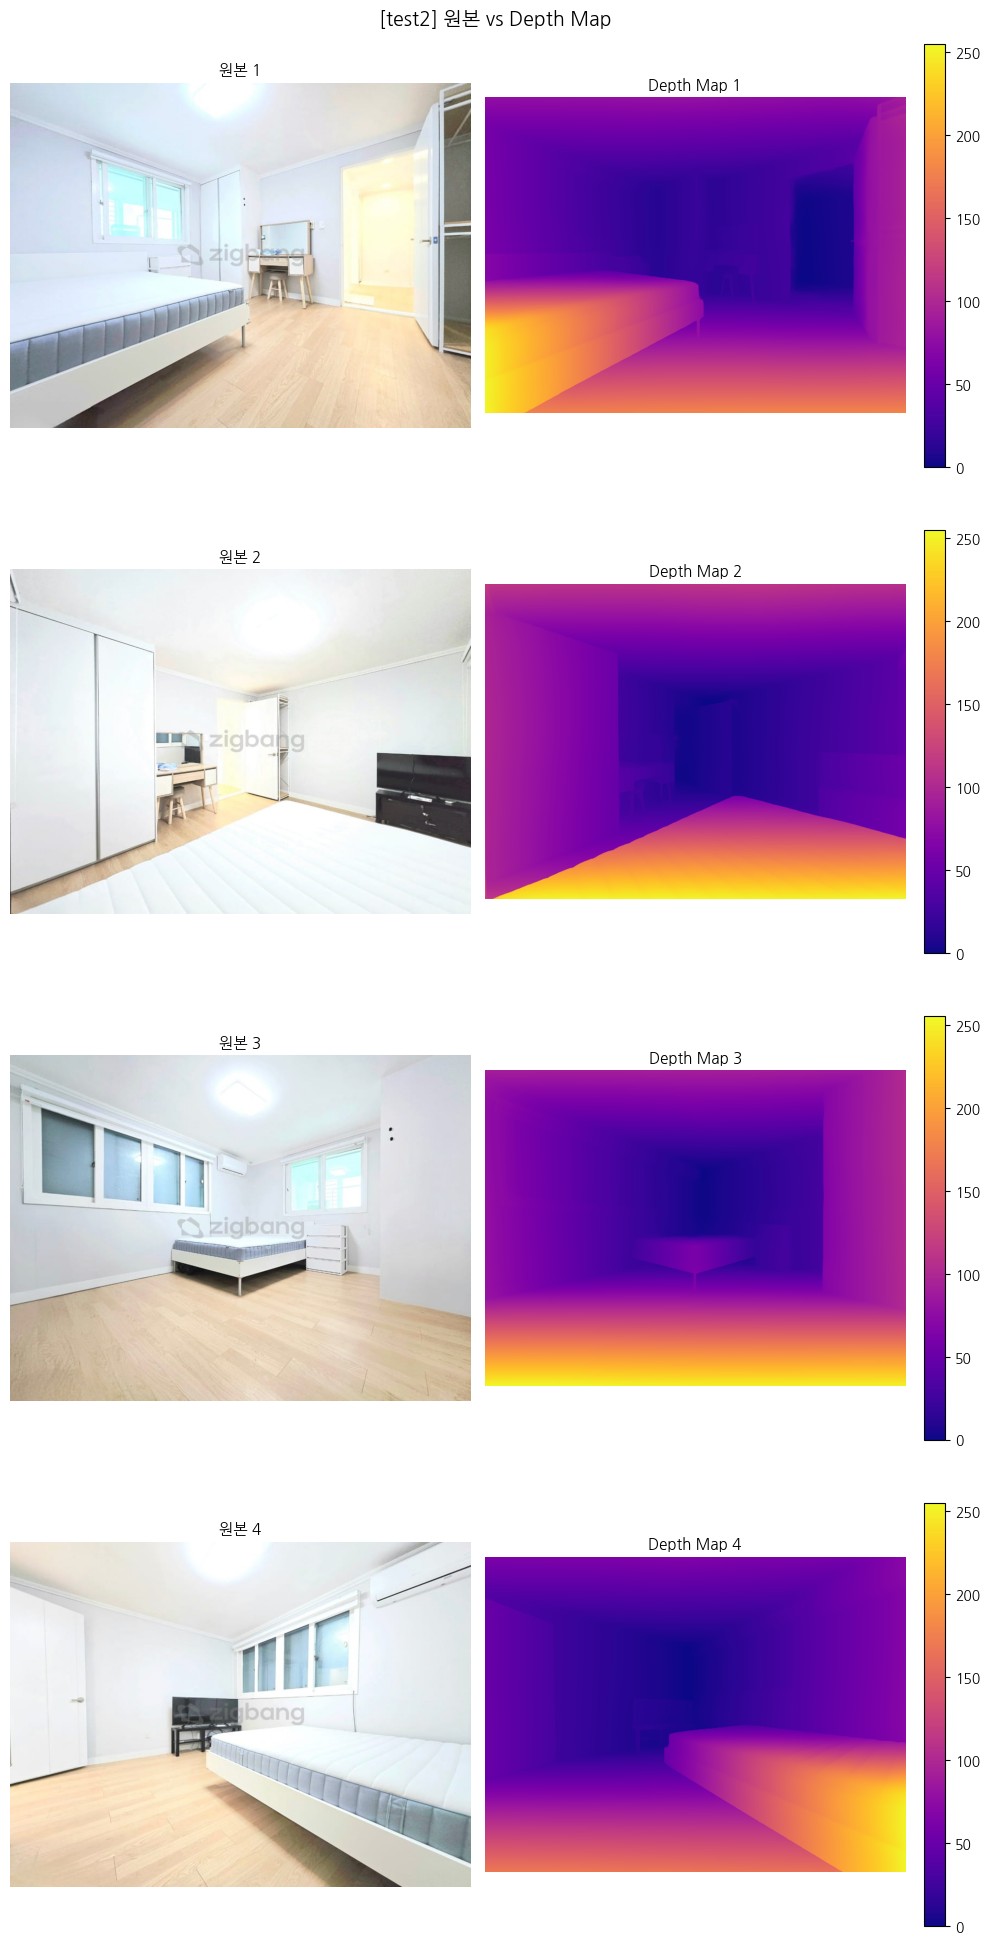

In [68]:
# 원본 vs 깊이맵 비교 시각화
n = len(img_paths)
fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))
if n == 1:
    axes = [axes]

for i, (img, depth) in enumerate(zip(images_pil, depth_maps)):
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"원본 {i + 1}", fontsize=11)
    axes[i][0].axis("off")

    im = axes[i][1].imshow(depth, cmap="plasma")
    axes[i][1].set_title(f"Depth Map {i + 1}", fontsize=11)
    axes[i][1].axis("off")
    plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)

plt.suptitle(f"[{TARGET_FOLDER}] 원본 vs Depth Map", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_ROOT / f"{TARGET_FOLDER}_depth.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. 3D 복원 (DUSt3R)

다중 뷰 이미지로부터 카메라 포즈와 3D pointmap을 동시에 추정한다.
이미지 쌍 간 매칭 후 global alignment로 전체 좌표계를 정렬한다.

In [69]:
import torch
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.inference import inference
from dust3r.cloud_opt import global_aligner

# DUSt3R 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device)
model.eval()
print(f"DUSt3R 모델 로드 완료 (device: {device})")


DUSt3R 모델 로드 완료 (device: cuda)


In [70]:
# 이미지 로드 및 쌍 구성 후 추론
images_dust3r = load_images(img_paths, size=512)
pairs = make_pairs(images_dust3r, scene_graph="complete", prefilter=None, symmetrize=True)
print(f"이미지 쌍 {len(pairs)}개 구성")

with torch.no_grad():
    output = inference(pairs, model, device, batch_size=2)

# Global alignment로 전체 좌표계 정렬
scene = global_aligner(output, device=device)
scene.compute_global_alignment(niter=300, init="mst")
print("3D 복원 및 정렬 완료")


>> Loading a list of 4 images
 - adding /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/1.jpg with resolution 853x640 --> 512x384
 - adding /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/2.jpg with resolution 853x640 --> 512x384
 - adding /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/3.jpg with resolution 853x640 --> 512x384
 - adding /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/4.jpg with resolution 853x640 --> 512x384
 (Found 4 images)
이미지 쌍 12개 구성
>> Inference with model on 12 image pairs


 init edge (0*,2*) score=np.float64(201.03326416015625)
 init edge (0,1*) score=np.float64(195.5935821533203)
 init edge (2,3*) score=np.float64(164.14215087890625)
 init loss = 0.010398036800324917
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


3D 복원 및 정렬 완료


In [71]:
# 전체 포인트 클라우드 추출 (신뢰도 필터링 적용)
# all_pts: 전체 3D 좌표 (N, 3), all_cols: 대응 색상 (N, 3), 0~1 정규화
pointmaps = scene.get_pts3d()
confidences = scene.get_conf()

all_pts, all_cols = [], []
for i, pts in enumerate(pointmaps):
    pts_np = pts.detach().cpu().numpy().reshape(-1, 3)
    conf_np = confidences[i].detach().cpu().numpy().flatten()
    mask = conf_np > CONF_THR

    h, w = pts.shape[:2]
    img_resized = np.array(images_pil[i].resize((w, h))).reshape(-1, 3)

    all_pts.append(pts_np[mask])
    all_cols.append(img_resized[mask])

all_pts = np.concatenate(all_pts, axis=0)
all_cols = np.concatenate(all_cols, axis=0) / 255.0
print(f"전체 포인트 수: {len(all_pts):,}")


전체 포인트 수: 771,811


## 3-1. DUSt3R 원본 복원 결과 저장 (선택)

객체 검출/색칠 이전의 순수한 3D 복원 결과를 GLB로 저장한다.
실제 사진 색을 그대로 사용하며, 객체 분리 전후 비교 자료로 활용할 수 있다.

참고: 여기서 `to_opengl` 함수를 먼저 정의하므로, 이후 7장 GLB 저장 섹션에서는 재정의하지 않는다.

In [72]:
# DUSt3R 원본 복원 결과를 GLB로 저장 (객체 검출 이전 단계)
import trimesh
from google.colab import files


def to_opengl(points):
    """DUSt3R 좌표계 -> OpenGL/GLB 좌표계 (Y, Z 반전)"""
    p = points.copy()
    p[:, 1] = -p[:, 1]
    p[:, 2] = -p[:, 2]
    return p


# 전체 포인트 클라우드를 실제 색상 그대로 저장
raw_pcd = trimesh.PointCloud(
    vertices=to_opengl(all_pts),
    colors=(all_cols * 255).astype(np.uint8),
)
raw_scene = trimesh.Scene()
raw_scene.add_geometry(raw_pcd, geom_name="dust3r_raw")

raw_glb_path = f"/content/{TARGET_FOLDER}_dust3r_raw.glb"
raw_scene.export(raw_glb_path)
print(f"DUSt3R 원본 복원 저장 완료: {raw_glb_path}")

files.download(raw_glb_path)


DUSt3R 원본 복원 저장 완료: /content/test2_dust3r_raw.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. 객체 검출 (YOLOv8)

각 이미지에서 가구를 검출하여 바운딩 박스를 얻는다.
검출된 박스는 다음 단계에서 SAM2의 입력 프롬프트로 사용한다.

In [73]:
!pip install -q ultralytics
from ultralytics import YOLO
import cv2

# YOLOv8 large 모델 로드 (가구 검출 정확도 우선)
model_yolo = YOLO("yolov8l.pt")
print("YOLO 모델 로드 완료")


YOLO 모델 로드 완료


In [74]:
# 객체 검출 실행 (conf: 신뢰도 임계값)
results_yolo = []
for path in img_paths:
    result = model_yolo(path, conf=0.3)
    results_yolo.append(result[0])

    print(f"\n{os.path.basename(path)}")
    for box in result[0].boxes:
        cls_name = model_yolo.names[int(box.cls)]
        print(f"  {cls_name} ({float(box.conf):.2f})")



image 1/1 /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/1.jpg: 480x640 1 chair, 1 bed, 12.4ms
Speed: 2.4ms preprocess, 12.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

1.jpg
  bed (0.85)
  chair (0.68)

image 1/1 /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/2.jpg: 480x640 1 chair, 17.4ms
Speed: 3.2ms preprocess, 17.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

2.jpg
  chair (0.62)

image 1/1 /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/3.jpg: 480x640 1 bed, 13.7ms
Speed: 3.2ms preprocess, 13.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

3.jpg
  bed (0.51)

image 1/1 /content/drive/MyDrive/0_ASAC_11기_DL_4조/02_Data/raw_room/room02/4.jpg: 480x640 1 bed, 1 tv, 11.9ms
Speed: 2.2ms preprocess, 11.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

4.jpg
  bed (0.90)
  tv (0.44)


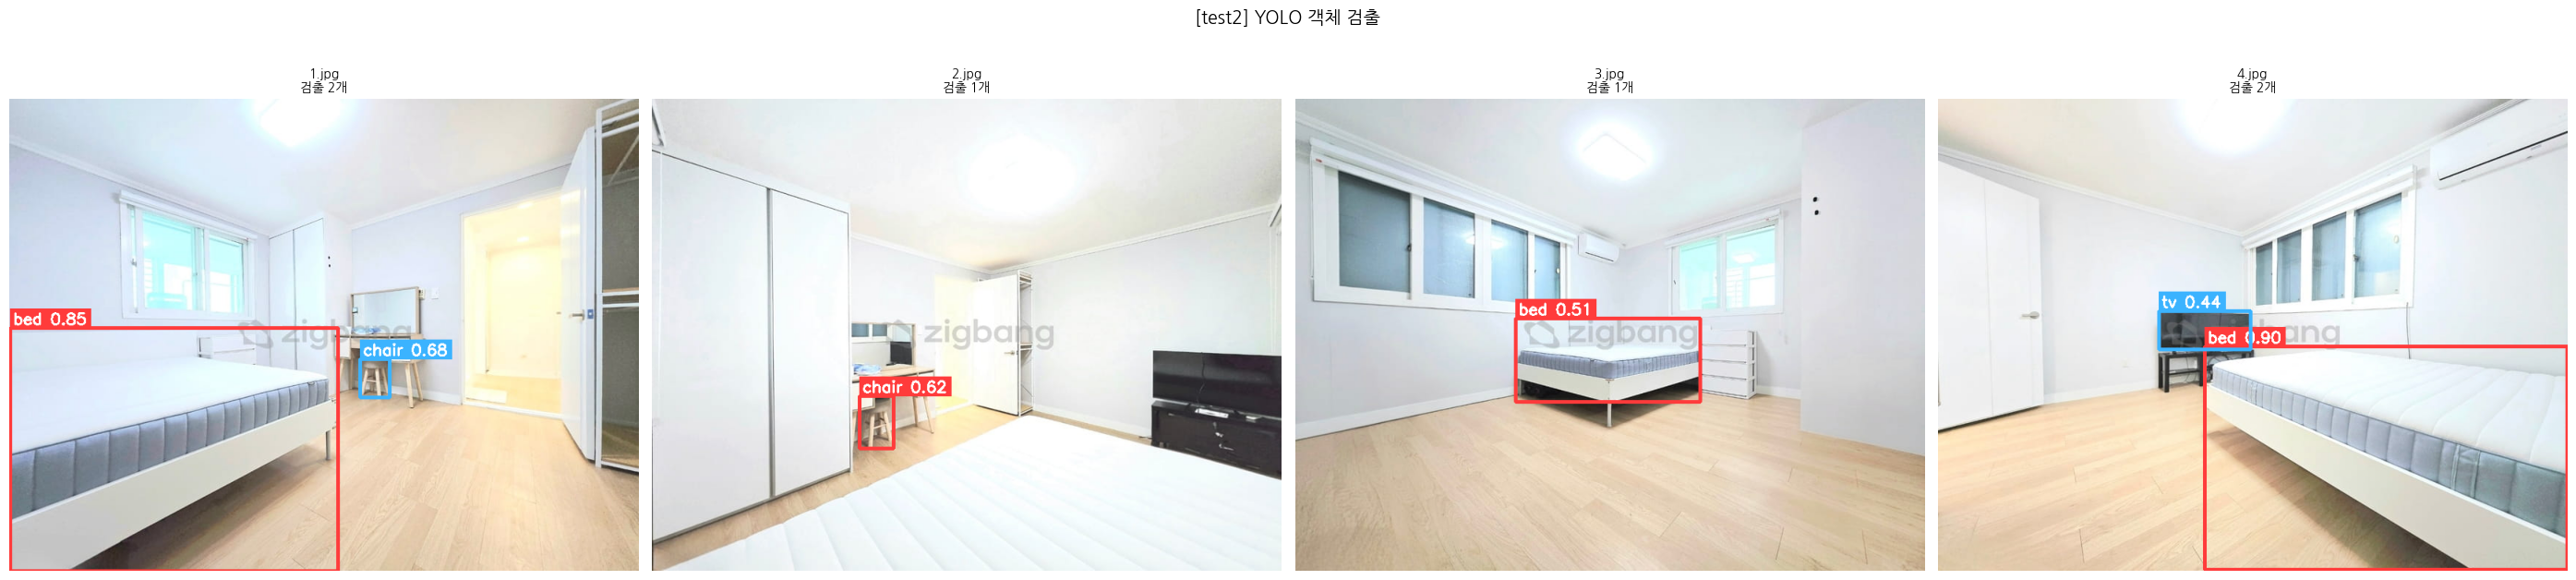

In [75]:
# 검출 결과 시각화 (바운딩 박스 + 라벨)
COLORS = [
    (255, 59, 59), (59, 179, 255), (59, 255, 107),
    (255, 200, 59), (200, 59, 255), (255, 130, 59),
]

n = len(img_paths)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, path, result in zip(axes, img_paths, results_yolo):
    img = np.array(Image.open(path).convert("RGB"))

    for i, box in enumerate(result.boxes):
        cls_name = model_yolo.names[int(box.cls)]
        conf = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = COLORS[i % len(COLORS)]

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        label = f"{cls_name} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img, (x1, y1 - th - 10), (x1 + tw + 8, y1), color, -1)
        cv2.putText(img, label, (x1 + 4, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    ax.imshow(img)
    ax.set_title(f"{os.path.basename(path)}\n검출 {len(result.boxes)}개", fontsize=10)
    ax.axis("off")

plt.suptitle(f"[{TARGET_FOLDER}] YOLO 객체 검출", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_ROOT / f"{TARGET_FOLDER}_yolo.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. 객체 마스크 생성 (SAM2)

YOLO 바운딩 박스를 프롬프트로 받아 픽셀 단위 마스크를 생성한다.
박스보다 정밀한 마스크를 얻어야 3D 좌표 연결 시 노이즈가 줄어든다.

In [76]:
!pip install -q sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# SAM2 predictor 로드 (체크포인트 자동 다운로드)
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")
print("SAM2 모델 로드 완료")


SAM2 모델 로드 완료


In [77]:
def get_masks_from_yolo(img_path, yolo_result, predictor):
    """YOLO 박스를 프롬프트로 SAM2 마스크 생성. (이미지, 마스크들, 박스들, 라벨들) 반환"""
    img = np.array(Image.open(img_path).convert("RGB"))

    with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
        predictor.set_image(img)
        masks_out, boxes_out, labels_out = [], [], []

        for box in yolo_result.boxes:
            cls_name = model_yolo.names[int(box.cls)]
            xyxy = box.xyxy[0].cpu().numpy()
            masks, _, _ = predictor.predict(box=xyxy, multimask_output=False)

            masks_out.append(masks[0])
            boxes_out.append(xyxy)
            labels_out.append(cls_name)

    return img, masks_out, boxes_out, labels_out


# 전체 이미지에 마스크 생성
all_results = []
for path, yolo_result in zip(img_paths, results_yolo):
    img, masks, boxes, labels = get_masks_from_yolo(path, yolo_result, predictor)
    all_results.append({"path": path, "img": img, "masks": masks,
                        "boxes": boxes, "labels": labels})
    print(f"{os.path.basename(path)}: 마스크 {len(masks)}개")


1.jpg: 마스크 2개
2.jpg: 마스크 1개
3.jpg: 마스크 1개
4.jpg: 마스크 2개


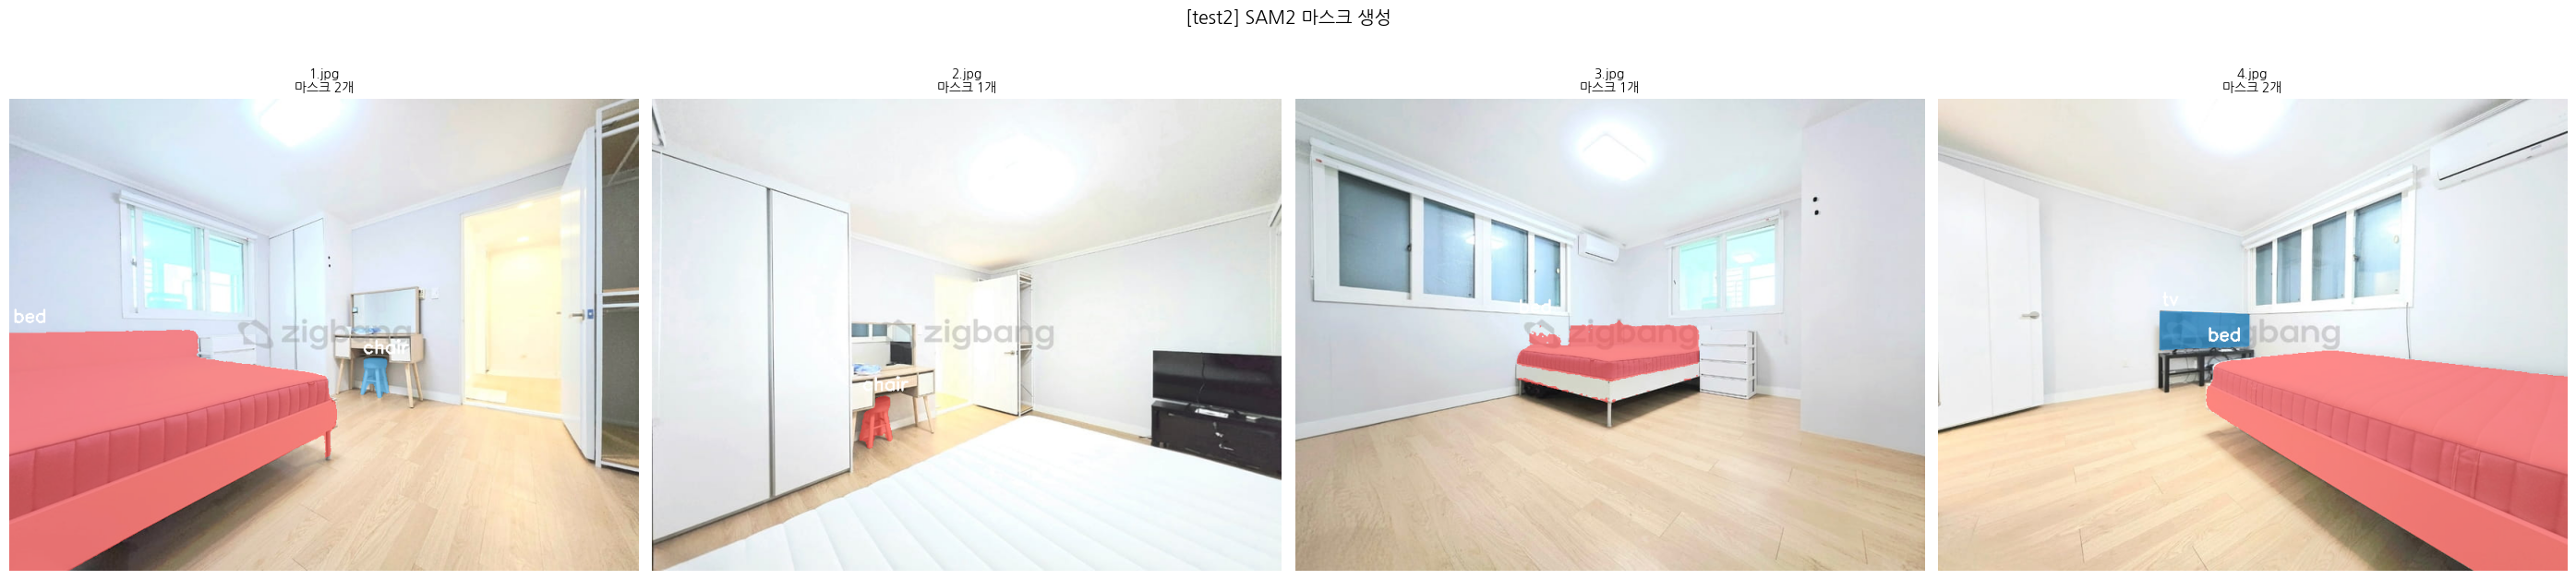

In [78]:
def draw_masks(img, masks, labels):
    """이미지 위에 반투명 마스크 오버레이"""
    overlay = img.copy().astype(np.float32)
    for i, mask in enumerate(masks):
        color = np.array(COLORS[i % len(COLORS)], dtype=np.float32)
        mask_bool = mask.astype(bool)   # float -> bool 변환
        overlay[mask_bool] = overlay[mask_bool] * 0.4 + color * 0.6
    return overlay.astype(np.uint8)


# 마스크 시각화
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, res in zip(axes, all_results):
    masked_img = draw_masks(res["img"], res["masks"], res["labels"])
    for box, label in zip(res["boxes"], res["labels"]):
        x1, y1 = int(box[0]), int(box[1])
        cv2.putText(masked_img, label, (x1 + 4, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    ax.imshow(masked_img)
    ax.set_title(f"{os.path.basename(res['path'])}\n마스크 {len(res['masks'])}개", fontsize=10)
    ax.axis("off")

plt.suptitle(f"[{TARGET_FOLDER}] SAM2 마스크 생성", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_ROOT / f"{TARGET_FOLDER}_sam2.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6. 2D 마스크 -> 3D 좌표 연결

DUSt3R의 pointmap은 각 픽셀이 이미 3D 좌표를 가지므로,
SAM2 마스크가 True인 픽셀의 3D 좌표만 추출하면 객체별 포인트 클라우드가 된다.
마스크와 pointmap의 해상도가 다르므로 마스크를 pointmap 크기로 리사이즈한다.
같은 라벨(예: bed)은 여러 이미지에 걸쳐 하나로 합친다.

In [79]:
from collections import defaultdict


def mask_to_3d(mask, pointmap, conf, conf_thr=CONF_THR):
    """2D 마스크 영역에 해당하는 3D 좌표 추출"""
    pts3d = pointmap.detach().cpu().numpy()
    conf_np = conf.detach().cpu().numpy()
    h, w = pts3d.shape[:2]

    # 마스크를 pointmap 해상도로 맞춤
    mask_resized = cv2.resize(
        mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
    ).astype(bool)

    valid = mask_resized & (conf_np > conf_thr)
    return pts3d[valid]


# 라벨별로 3D 점 수집 후 병합
objects_3d = defaultdict(list)
for i, res in enumerate(all_results):
    for j, label in enumerate(res["labels"]):
        obj_pts = mask_to_3d(res["masks"][j], pointmaps[i], confidences[i])
        if len(obj_pts) < 50:   # 점이 너무 적으면 노이즈로 간주
            continue
        objects_3d[label].append(obj_pts)

objects_3d = {
    label: np.concatenate(pts_list, axis=0)
    for label, pts_list in objects_3d.items()
}

for label, pts in objects_3d.items():
    print(f"{label}: {len(pts):,}개")


bed: 75,379개
chair: 1,015개
tv: 1,884개


## 7. 객체별 색상 3D 모델 저장 (GLB)

객체를 라벨별 고정 색상으로 칠하고 전체 공간과 함께 GLB로 저장한다.
`save_3d_objects` 함수는 DUSt3R 기본 함수 `get_3D_model_from_scene`의
주요 옵션(point cloud/mesh, 노이즈 제거, 카메라 표시)을 직접 구현한 것이다.

좌표 보정 참고: DUSt3R 좌표계는 표준 GLB 뷰어와 Y, Z축 방향이 반대이므로
`to_opengl`로 부호를 뒤집어 정방향으로 저장한다.

In [80]:
import trimesh
import open3d as o3d
from google.colab import files

# 라벨별 고정 색상 (어느 이미지에서 검출되든 같은 색 유지)
LABEL_COLORS = {
    "bed":          [255, 59, 59],    # 빨강
    "refrigerator": [59, 255, 107],   # 초록
    "oven":         [200, 59, 255],   # 보라
    "microwave":    [255, 200, 59],   # 노랑
    "sink":         [59, 179, 255],   # 파랑
    "couch":        [255, 130, 59],   # 주황
    "chair":        [59, 255, 220],   # 청록
    "dining table": [255, 59, 180],   # 핑크
    "tv":           [150, 150, 255],  # 연보라
    "potted plant": [120, 255, 120],  # 연두
}
DEFAULT_COLOR = [180, 180, 180]   # 매핑 없는 객체는 회색


# to_opengl 함수는 3-1 섹션에서 이미 정의됨

def clean_pointcloud(points, colors=None, n_neighbors=20, std_ratio=2.0):
    """통계적 이상치 제거 (clean_depth 옵션에 해당)"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    clean, _ = pcd.remove_statistical_outlier(n_neighbors, std_ratio)
    pts = np.asarray(clean.points)
    cols = np.asarray(clean.colors) if colors is not None else None
    return pts, cols


def add_cameras(scene_export, scene, cam_size=0.1):
    """카메라 위치를 frustum 선으로 표시 (transparent_cams 옵션에 해당)"""
    poses = scene.get_im_poses().detach().cpu().numpy()
    cam_colors = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0], [255, 0, 255]]

    for i, pose in enumerate(poses):
        color = cam_colors[i % len(cam_colors)]
        s = cam_size
        pts_local = np.array([
            [0, 0, 0], [-s, -s, s * 1.5], [s, -s, s * 1.5],
            [s, s, s * 1.5], [-s, s, s * 1.5],
        ])
        pts_world = (pose[:3, :3] @ pts_local.T).T + pose[:3, 3]
        pts_world[:, 1] = -pts_world[:, 1]
        pts_world[:, 2] = -pts_world[:, 2]

        edges = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (2, 3), (3, 4), (4, 1)]
        for a, b in edges:
            line = trimesh.load_path(np.array([pts_world[a], pts_world[b]]))
            line.colors = np.array([color + [255]])
            scene_export.add_geometry(line, geom_name=f"cam_{i}_{a}{b}")
    return scene_export


In [81]:
def save_3d_objects(all_pts, all_cols, objects_3d, scene, target_name,
                    as_pointcloud=True, clean_depth=False, transparent_cams=False):
    """객체별 색상 3D 모델을 GLB로 저장

    as_pointcloud   : True면 점 구름, False면 convex hull 메시(덩어리)
    clean_depth     : True면 통계적 이상치 제거
    transparent_cams: True면 카메라 위치 frustum 추가
    """
    scene_export = trimesh.Scene()

    # 전체 공간 (배경)
    room_pts, room_cols = all_pts, all_cols
    if clean_depth:
        room_pts, room_cols = clean_pointcloud(room_pts, room_cols)
    full_pcd = trimesh.PointCloud(
        vertices=to_opengl(room_pts),
        colors=(room_cols * 255).astype(np.uint8),
    )
    scene_export.add_geometry(full_pcd, geom_name="room")

    # 객체별 (라벨 고정 색)
    for label, pts in objects_3d.items():
        color = LABEL_COLORS.get(label, DEFAULT_COLOR)
        obj_pts = pts
        if clean_depth:
            obj_pts, _ = clean_pointcloud(obj_pts, n_neighbors=10)

        if as_pointcloud:
            colors = np.tile(color, (len(obj_pts), 1)).astype(np.uint8)
            geom = trimesh.PointCloud(vertices=to_opengl(obj_pts), colors=colors)
        else:
            geom = trimesh.PointCloud(vertices=to_opengl(obj_pts)).convex_hull
            geom.visual.face_colors = color + [200]

        scene_export.add_geometry(geom, geom_name=label)
        print(f"  {label}: {len(obj_pts):,}개")

    if transparent_cams:
        scene_export = add_cameras(scene_export, scene)

    glb_path = f"/content/{target_name}.glb"
    scene_export.export(glb_path)
    print(f"저장 완료: {glb_path}")
    return glb_path


In [82]:
# GLB 저장 및 다운로드
# as_pointcloud=False -> 가구를 덩어리(메시) 형태로 단순화
glb_path = save_3d_objects(
    all_pts, all_cols, objects_3d, scene,
    target_name=f"{TARGET_FOLDER}_objects",
    as_pointcloud=False,
    clean_depth=True,
    transparent_cams=False,
)
files.download(glb_path)


  bed: 73,206개
  chair: 970개
  tv: 1,793개
저장 완료: /content/test2_objects.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7-1. 방 텍스처 메시 위에 객체 메시 얹기 (GLB)

방 전체를 텍스처(원본 색) 입힌 삼각 메시로 깔고, 그 위에 검출된 객체를
라벨 고정색 메시로 얹어 GLB로 저장한다.

DUSt3R 내장 함수(`pts3d_to_trimesh`, `cat_meshes`, `_convert_scene_output_to_glb`)와
**동일한 방식**으로 메시를 만든다. 직접 짠 Delaunay 삼각분할 대신 내장 방식을 쓰는 이유:

- 메시를 (H, W) 픽셀 격자 구조로 잇는다. 인접 픽셀 4개로 사각형(삼각형 2개)을 만들고
  `valid` 마스크로 면을 거른다. 경계가 깔끔하고 늘어진 삼각형이 안 생긴다.
- 좌표 정렬을 `to_opengl`(Y, Z 부호 반전)이 아니라 카메라 포즈 행렬로 한 번에 처리한다.
- conf 마스킹은 `scene.get_masks()`를 그대로 쓰며, 임계값 단위가 `CONF_THR`(1.0)과 다르다.
  내장 함수 기본값인 `min_conf_thr=3`을 사용해야 결과가 정상으로 나온다.
- 노이즈 심하면 min_conf_thr=5 / 듬성듬성이면 min_conf_thr 2 내리기
객체는 같은 `pts3d` 격자에 객체 마스크를 `valid`로 넣어 만들고,
색은 라벨색으로 채운 단색 이미지를 `pts3d_to_trimesh`에 넘겨 입힌다.

In [83]:
import numpy as np
import torch
import trimesh
import cv2
from scipy.spatial.transform import Rotation
from google.colab import files

# DUSt3R 내장 헬퍼/상수 그대로 재사용
from dust3r.demo import pts3d_to_trimesh, cat_meshes
from dust3r.utils.device import to_numpy
try:
    from dust3r.demo import OPENGL
except ImportError:
    from dust3r.viz import OPENGL


def save_room_and_objects_glb(scene, all_results, target_name,
                              min_conf_thr=3, clean_depth=True,
                              output_dir="/content"):
    """방 텍스처 메시 위에 객체 라벨색 메시를 얹어 GLB로 저장.

    DUSt3R 내장 _convert_scene_output_to_glb(as_pointcloud=False)와 같은 방식으로
    방 메시를 만들고, 좌표 정렬도 동일한 카메라 포즈 행렬로 처리한다.

    min_conf_thr : 내장 함수 기준 신뢰도 임계값. CONF_THR(1.0)이 아니라 내장 기본값 3을 쓴다.
                   (scene.conf_trf로 변환되므로 단위가 다름)
    clean_depth  : True면 내장 clean_pointcloud로 이상치 제거
    """
    if clean_depth:
        scene = scene.clean_pointcloud()

    rgbimg = scene.imgs                              # 이미지별 (H, W, 3), 0~1
    focals = to_numpy(scene.get_focals().cpu())
    cams2world = to_numpy(scene.get_im_poses().cpu())
    pts3d = to_numpy(scene.get_pts3d())              # 이미지별 (H, W, 3)
    scene.min_conf_thr = float(scene.conf_trf(torch.tensor(min_conf_thr)))
    msk = to_numpy(scene.get_masks())                # 이미지별 (H, W) bool

    out = trimesh.Scene()

    # 1) 방 전체 텍스처 메시 (내장 방식과 동일)
    room_meshes = [pts3d_to_trimesh(rgbimg[i], pts3d[i], msk[i]) for i in range(len(rgbimg))]
    room_mesh = trimesh.Trimesh(**cat_meshes(room_meshes))
    out.add_geometry(room_mesh)

    # 2) 객체 라벨색 메시를 그 위에 얹음 (같은 pts3d 격자 + 객체 마스크)
    for i, res in enumerate(all_results):
        H, W = pts3d[i].shape[:2]
        for j, label in enumerate(res["labels"]):
            color = LABEL_COLORS.get(label, DEFAULT_COLOR)

            # YOLO/SAM 마스크를 pointmap 해상도로 맞추고 conf 마스크와 교집합
            obj_mask = cv2.resize(res["masks"][j].astype(np.uint8), (W, H),
                                  interpolation=cv2.INTER_NEAREST).astype(bool)
            valid = obj_mask & msk[i]
            if valid.sum() < 3:
                continue

            # 라벨 단색 이미지를 넣어 face_colors가 라벨색이 되게 함
            solid = np.zeros((H, W, 3), dtype=np.float32)
            solid[:] = np.array(color) / 255.0
            md = pts3d_to_trimesh(solid, pts3d[i], valid)
            if len(md["faces"]) == 0:
                continue
            obj_mesh = trimesh.Trimesh(**md)
            out.add_geometry(obj_mesh, geom_name=f"{label}_{i}_{j}")
            print(f"  {label} (img{i}): 면 {len(md['faces'])}개")

    # 3) 좌표 정렬: 내장 _convert_scene_output_to_glb와 동일한 변환
    rot = np.eye(4)
    rot[:3, :3] = Rotation.from_euler("y", np.deg2rad(180)).as_matrix()
    out.apply_transform(np.linalg.inv(cams2world[0] @ OPENGL @ rot))

    glb_path = f"{output_dir}/{target_name}_room_objects_mesh.glb"
    out.export(glb_path)
    print("저장 완료:", glb_path)
    return glb_path


In [84]:
# 방 메시 + 객체 메시 GLB 저장 및 다운로드
glb_path = save_room_and_objects_glb(
    scene, all_results,
    target_name=TARGET_FOLDER,
    min_conf_thr=3,     # 내장 함수 기본값 (CONF_THR 아님). 높이면 면이 줄고 낮추면 늘어난다
    clean_depth=True,
)
files.download(glb_path)


  bed (img0): 면 123446개
  chair (img0): 면 220개
  chair (img1): 면 668개
  bed (img2): 면 6416개
  bed (img3): 면 138742개
저장 완료: /content/test2_room_objects_mesh.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 바닥 투영 (Top View)

3D 객체를 위에서 내려다본 2D 평면으로 투영한다. 두 방법을 비교한다.

- 단순 투영: 높이축(Y)을 무시하고 나머지 두 축만 사용. 빠르지만 방이 기울면 왜곡됨.
- RANSAC 투영: 바닥 평면을 검출해 그 평면 기준으로 투영. 바닥이 기울어도 정렬됨.

바닥 법선의 Y 성분이 1에 가까우면 바닥이 거의 수평이라는 의미이며,
이 경우 두 방법의 결과가 비슷하게 나온다.

In [85]:
def project_simple(points, up_axis=1):
    """단순 투영: 높이축을 제외한 두 축만 사용"""
    axes = [a for a in range(3) if a != up_axis]
    return points[:, axes]


def project_ransac(points, n_iter=2000, threshold=None, up_axis=1):
    """RANSAC으로 바닥 평면을 검출하고 그 평면 기준으로 투영. (2D좌표, 법선) 반환"""
    if threshold is None:
        diag = np.linalg.norm(points.max(axis=0) - points.min(axis=0))
        threshold = diag * 0.02

    # 바닥 후보: 높이 하위 30% 점
    height = points[:, up_axis]
    floor_candidates = points[height <= np.percentile(height, 30)]

    best_inliers, best_plane = None, None
    for _ in range(n_iter):
        idx = np.random.choice(len(floor_candidates), 3, replace=False)
        p1, p2, p3 = floor_candidates[idx]
        normal = np.cross(p2 - p1, p3 - p1)
        norm = np.linalg.norm(normal)
        if norm < 1e-6:
            continue
        normal = normal / norm

        d = -np.dot(normal, p1)
        dist = np.abs(floor_candidates @ normal + d)
        inliers = dist < threshold
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers, best_plane = inliers, (normal, d)

    normal, _ = best_plane
    if normal[up_axis] < 0:
        normal = -normal

    # 평면 위 두 축(u, v)을 만들어 투영
    u = np.cross(normal, [1, 0, 0])
    if np.linalg.norm(u) < 1e-6:
        u = np.cross(normal, [0, 1, 0])
    u = u / np.linalg.norm(u)
    v = np.cross(normal, u)

    projected = np.stack([points @ u, points @ v], axis=1)
    return projected, normal


print("투영 함수 정의 완료")


투영 함수 정의 완료


바닥 법선: [0.03, 1.00, 0.04]


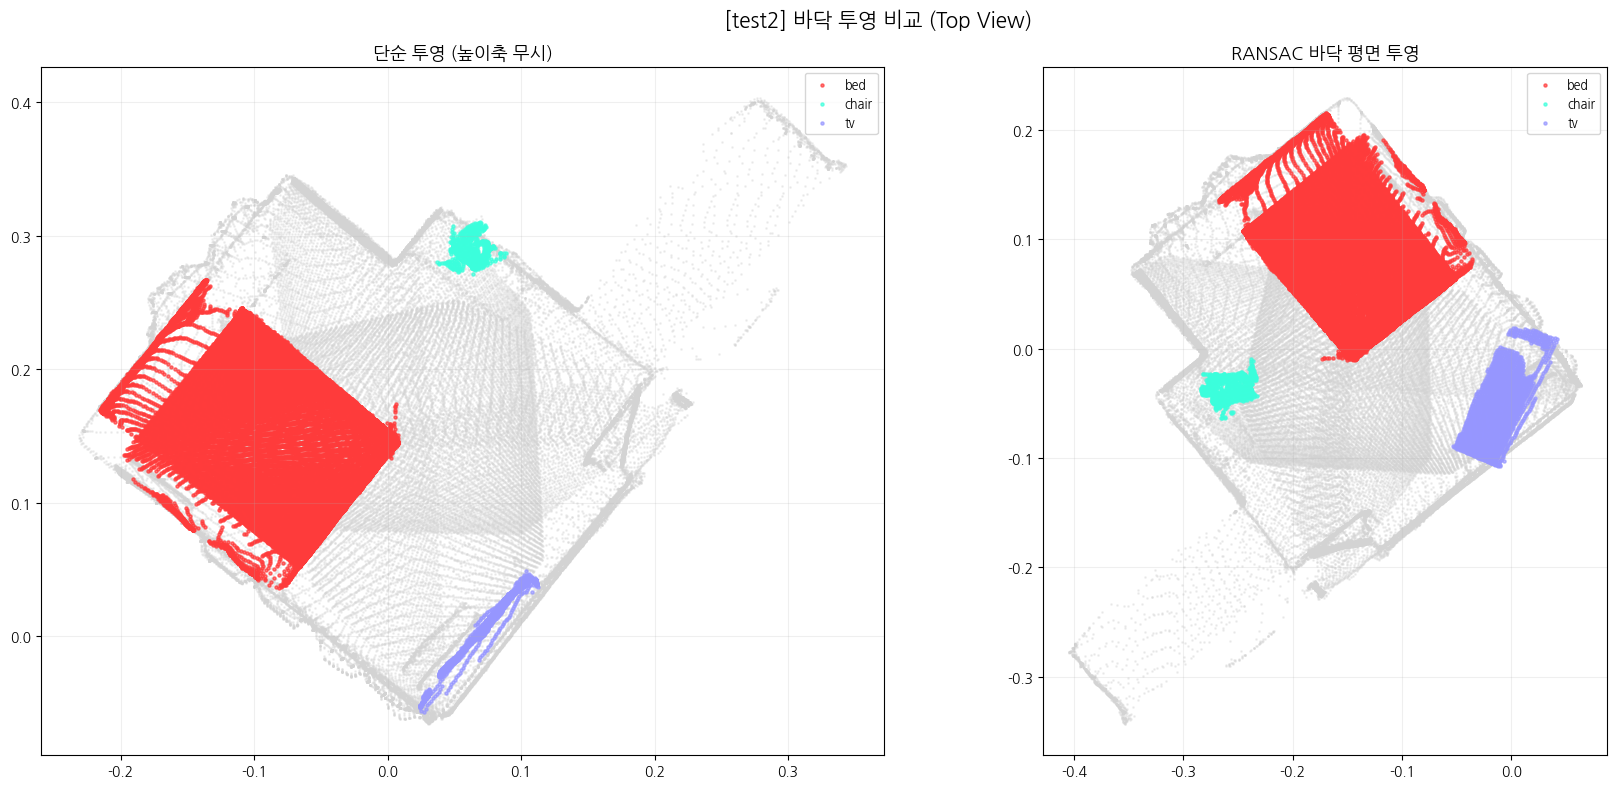

In [86]:
# RANSAC 투영은 한 번만 계산해 재사용
room_2d_ransac, normal = project_ransac(all_pts)
print(f"바닥 법선: [{normal[0]:.2f}, {normal[1]:.2f}, {normal[2]:.2f}]")

objects_2d_ransac = {
    label: project_ransac(pts)[0] for label, pts in objects_3d.items()
}

# 두 방법 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, method in zip(axes, ["simple", "ransac"]):
    room_2d = project_simple(all_pts) if method == "simple" else room_2d_ransac
    ax.scatter(room_2d[::10, 0], room_2d[::10, 1], c="lightgray", s=1, alpha=0.3)

    for label, pts in objects_3d.items():
        color = np.array(LABEL_COLORS.get(label, DEFAULT_COLOR)) / 255
        obj_2d = project_simple(pts) if method == "simple" else objects_2d_ransac[label]
        ax.scatter(obj_2d[:, 0], obj_2d[:, 1], c=[color], s=5, alpha=0.7, label=label)

    title = "단순 투영 (높이축 무시)" if method == "simple" else "RANSAC 바닥 평면 투영"
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.2)

plt.suptitle(f"[{TARGET_FOLDER}] 바닥 투영 비교 (Top View)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_ROOT / f"{TARGET_FOLDER}_floor_compare.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. 도형 단순화 및 평면도 생성

투영된 객체 점들을 최소 외접 사각형으로 단순화하여 평면도를 그린다.
각 사각형에 가구 이름과 크기(상대 단위)를 함께 표시한다.

In [87]:
def fit_shape(points_2d):
    """2D 점들을 최소 면적 회전 사각형으로 단순화"""
    rect = cv2.minAreaRect(points_2d.astype(np.float32))   # ((cx,cy),(w,h),angle)
    box = cv2.boxPoints(rect)
    (cx, cy), (w, h), angle = rect
    return {"box": box, "center": (cx, cy), "size": (w, h), "angle": angle}


print("도형 피팅 함수 정의 완료")


도형 피팅 함수 정의 완료


객체별 도형 크기 (상대 단위)
  bed: 0.193 x 0.171
  chair: 0.045 x 0.041
  tv: 0.018 x 0.131


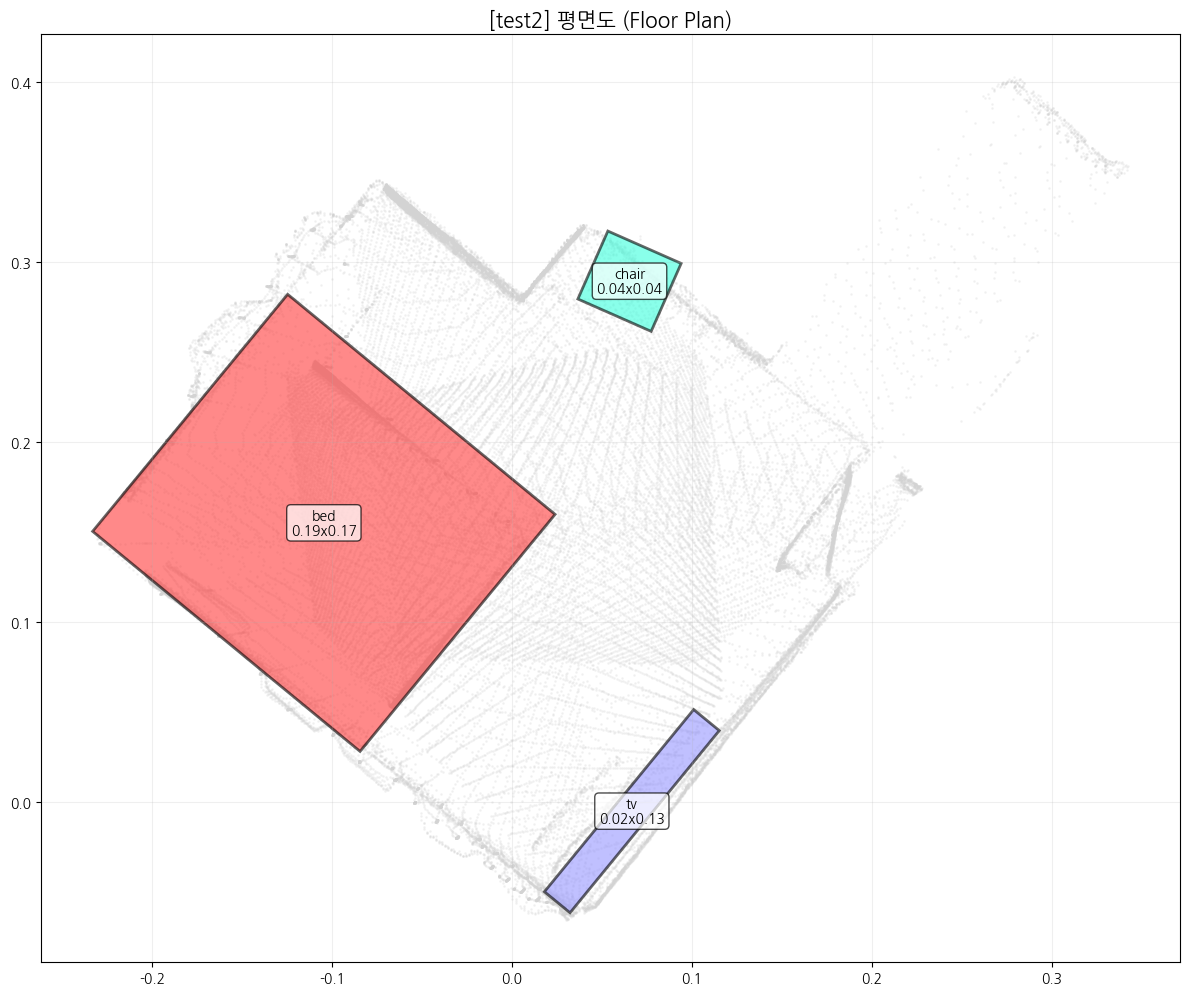

In [88]:
from matplotlib.patches import Polygon

# 투영 방법 선택 (simple / ransac)
USE_METHOD = "simple"

fig, ax = plt.subplots(figsize=(12, 12))

# 방 외곽 (회색 점)
room_2d = project_simple(all_pts) if USE_METHOD == "simple" else room_2d_ransac
ax.scatter(room_2d[::15, 0], room_2d[::15, 1], c="lightgray", s=1, alpha=0.2)

# 객체별 사각형 도형 + 라벨/크기
print("객체별 도형 크기 (상대 단위)")
for label, pts in objects_3d.items():
    color = np.array(LABEL_COLORS.get(label, DEFAULT_COLOR)) / 255
    obj_2d = project_simple(pts) if USE_METHOD == "simple" else objects_2d_ransac[label]
    shape = fit_shape(obj_2d)

    poly = Polygon(shape["box"], closed=True, facecolor=color,
                   edgecolor="black", alpha=0.6, linewidth=2)
    ax.add_patch(poly)

    cx, cy = shape["center"]
    w, h = shape["size"]
    ax.text(cx, cy, f"{label}\n{w:.2f}x{h:.2f}", ha="center", va="center",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    print(f"  {label}: {w:.3f} x {h:.3f}")

ax.set_title(f"[{TARGET_FOLDER}] 평면도 (Floor Plan)", fontsize=15, fontweight="bold")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(str(OUTPUT_ROOT / f"{TARGET_FOLDER}_floorplan.png"), dpi=150, bbox_inches="tight")
plt.show()


객체별 도형 크기 (상대 단위)
  bed: 0.193 x 0.171
  chair: 0.045 x 0.041
  tv: 0.018 x 0.131


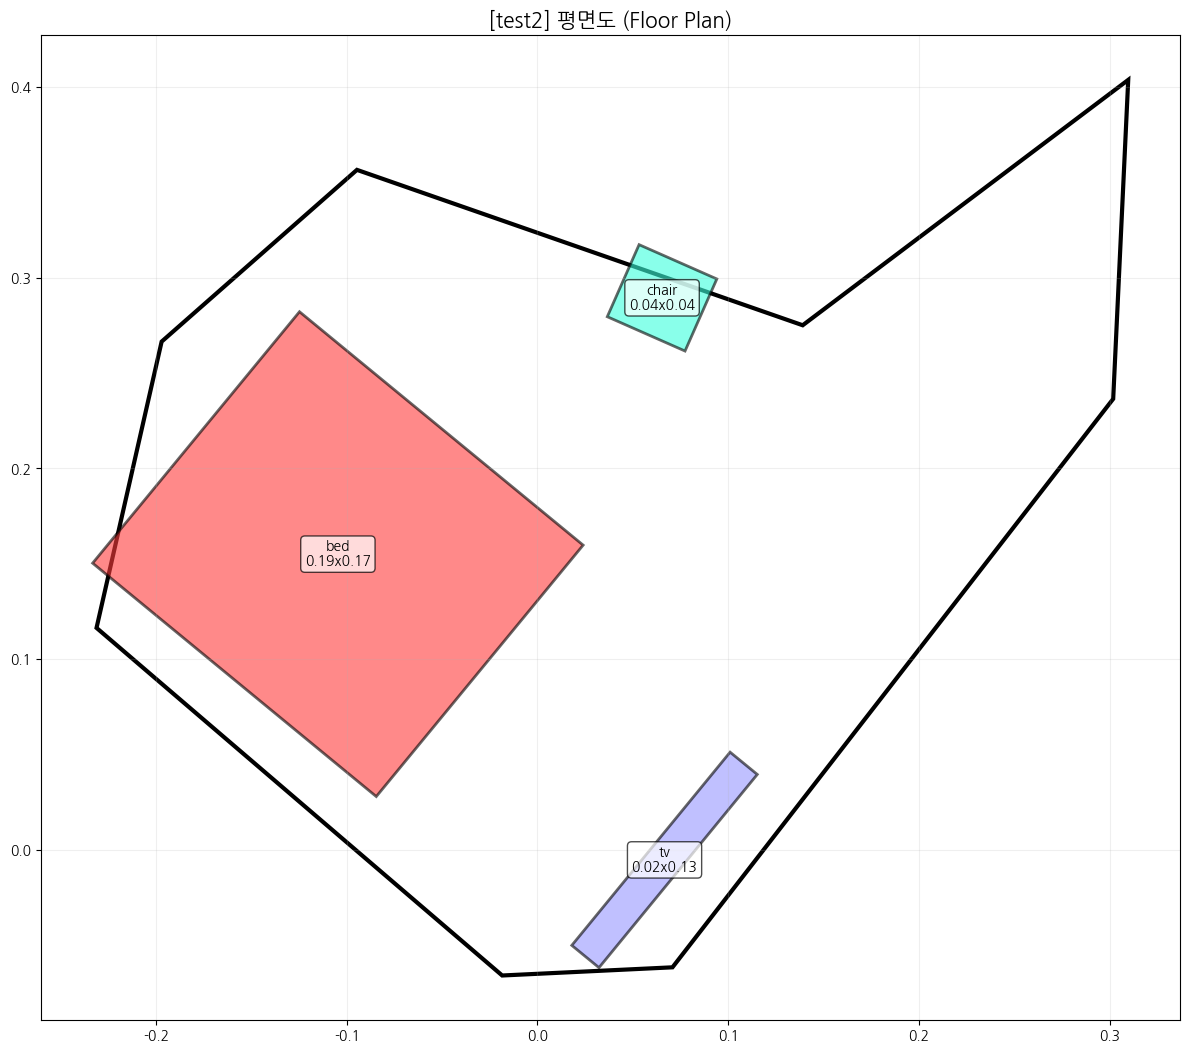

In [89]:
from matplotlib.patches import Polygon


def room_outline(pts_2d, grid_res=220, close_k=7, eps_ratio=0.012):
    """2D 점들을 점유격자로 만든 뒤 외곽 컨투어를 따서 방 경계로 반환"""
    mn, mx = pts_2d.min(0), pts_2d.max(0)
    span = np.where((mx - mn) > 1e-9, mx - mn, 1e-9)
    gx = ((pts_2d[:, 0] - mn[0]) / span[0] * (grid_res - 1)).astype(int)
    gy = ((pts_2d[:, 1] - mn[1]) / span[1] * (grid_res - 1)).astype(int)

    grid = np.zeros((grid_res, grid_res), np.uint8)
    grid[gy, gx] = 255
    kernel = np.ones((close_k, close_k), np.uint8)
    grid = cv2.morphologyEx(grid, cv2.MORPH_CLOSE, kernel)   # 작은 구멍 메움
    grid = cv2.dilate(grid, kernel, 1)

    cnts, _ = cv2.findContours(grid, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(cnts, key=cv2.contourArea)
    eps = eps_ratio * cv2.arcLength(cnt, True)
    cnt = cv2.approxPolyDP(cnt, eps, True).reshape(-1, 2).astype(float)

    # 격자좌표 -> 원래 좌표로 환원
    cnt[:, 0] = cnt[:, 0] / (grid_res - 1) * span[0] + mn[0]
    cnt[:, 1] = cnt[:, 1] / (grid_res - 1) * span[1] + mn[1]
    return cnt


# 투영 방법 선택 (simple / ransac)
USE_METHOD = "simple"

room_2d = project_simple(all_pts) if USE_METHOD == "simple" else room_2d_ransac

fig, ax = plt.subplots(figsize=(12, 12))

# 방 외곽선
wall = room_outline(room_2d, close_k=13, eps_ratio=0.025)
ax.add_patch(Polygon(wall, closed=True, fill=False,
                     edgecolor="black", linewidth=3))

# 객체별 사각형 도형 + 라벨/크기
print("객체별 도형 크기 (상대 단위)")
for label, pts in objects_3d.items():
    color = np.array(LABEL_COLORS.get(label, DEFAULT_COLOR)) / 255
    obj_2d = project_simple(pts) if USE_METHOD == "simple" else objects_2d_ransac[label]
    shape = fit_shape(obj_2d)

    poly = Polygon(shape["box"], closed=True, facecolor=color,
                   edgecolor="black", alpha=0.6, linewidth=2)
    ax.add_patch(poly)

    cx, cy = shape["center"]
    w, h = shape["size"]
    ax.text(cx, cy, f"{label}\n{w:.2f}x{h:.2f}", ha="center", va="center",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    print(f"  {label}: {w:.3f} x {h:.3f}")

ax.set_title(f"[{TARGET_FOLDER}] 평면도 (Floor Plan)", fontsize=15, fontweight="bold")
ax.set_aspect("equal")
ax.autoscale_view()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(str(OUTPUT_ROOT / f"{TARGET_FOLDER}_floorplan.png"), dpi=150, bbox_inches="tight")
plt.show()


In [90]:
import numpy as np

def looks_like_points(v):
    if not isinstance(v, np.ndarray):
        return False
    if v.ndim < 2 or v.shape[-1] != 3:
        return False
    if v.size < 300:  # 너무 작은 건 제외
        return False
    return True

cands = []
for name, val in list(globals().items()):
    if name.startswith("_"):
        continue
    try:
        if looks_like_points(val):
            cands.append((name, val.shape, val.dtype))
    except Exception:
        pass

if cands:
    print("포인트처럼 보이는 변수:")
    for name, shape, dtype in cands:
        print(f"  {name}: shape={shape}, dtype={dtype}")
else:
    print("끝 차원이 3인 큰 배열이 안 보임. 복원 셀을 먼저 돌렸는지 확인 필요")


포인트처럼 보이는 변수:
  img: shape=(640, 853, 3), dtype=uint8
  all_pts: shape=(771811, 3), dtype=float32
  all_cols: shape=(771811, 3), dtype=float64
  pts: shape=(1884, 3), dtype=float32
  pts_np: shape=(196608, 3), dtype=float32
  img_resized: shape=(196608, 3), dtype=uint8
  masked_img: shape=(640, 853, 3), dtype=uint8
  obj_pts: shape=(1884, 3), dtype=float32


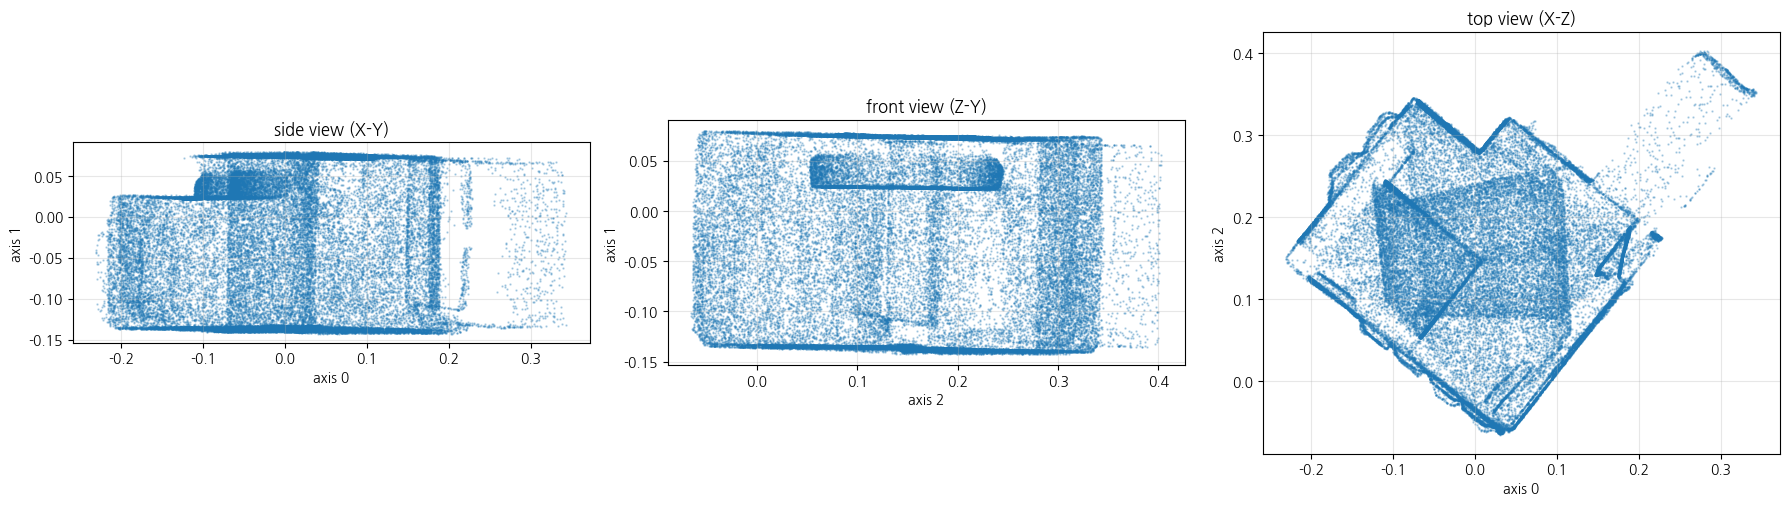

In [91]:
import numpy as np
import matplotlib.pyplot as plt

pts = all_pts   # 이미 (N,3)라 reshape 불필요

# 유한값만 남기기
pts = pts[np.isfinite(pts).all(axis=1)]

# 다운샘플 (그림용)
if len(pts) > 50000:
    idx = np.random.choice(len(pts), 50000, replace=False)
    pts = pts[idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

projections = [
    ("side view (X-Y)", 0, 1),
    ("front view (Z-Y)", 2, 1),
    ("top view (X-Z)", 0, 2),
]

for ax, (title, a, b) in zip(axes, projections):
    ax.scatter(pts[:, a], pts[:, b], s=0.5, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("axis " + str(a))
    ax.set_ylabel("axis " + str(b))
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


높이 범위: -0.143 ~ 0.080
전체 771811 -> 벽 띠 113055


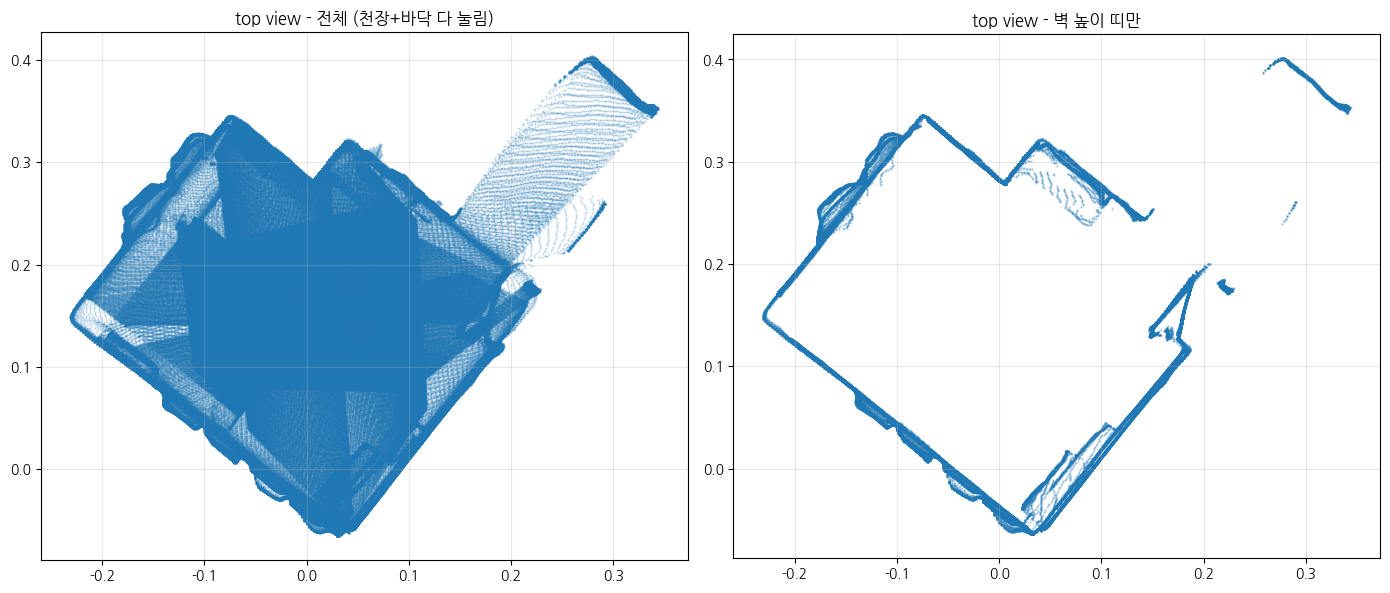

In [92]:
import numpy as np
import matplotlib.pyplot as plt

pts = all_pts[np.isfinite(all_pts).all(axis=1)]

up = pts[:, 1]   # axis 1 = 위 방향
lo, hi = up.min(), up.max()
print(f"높이 범위: {lo:.3f} ~ {hi:.3f}")

# 가운데 높이 띠만 추출 (바닥/천장 제외, 벽 위주)
band_lo = lo + (hi - lo) * 0.35
band_hi = lo + (hi - lo) * 0.65
wall = pts[(up > band_lo) & (up < band_hi)]
print(f"전체 {len(pts)} -> 벽 띠 {len(wall)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 전체 top view (지금 깨져 보이는 그림)
axes[0].scatter(pts[:, 0], pts[:, 2], s=0.5, alpha=0.2)
axes[0].set_title("top view - 전체 (천장+바닥 다 눌림)")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3)

# 오른쪽: 가운데 높이 띠만 (벽 윤곽이 드러남)
axes[1].scatter(wall[:, 0], wall[:, 2], s=0.5, alpha=0.3)
axes[1].set_title("top view - 벽 높이 띠만")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


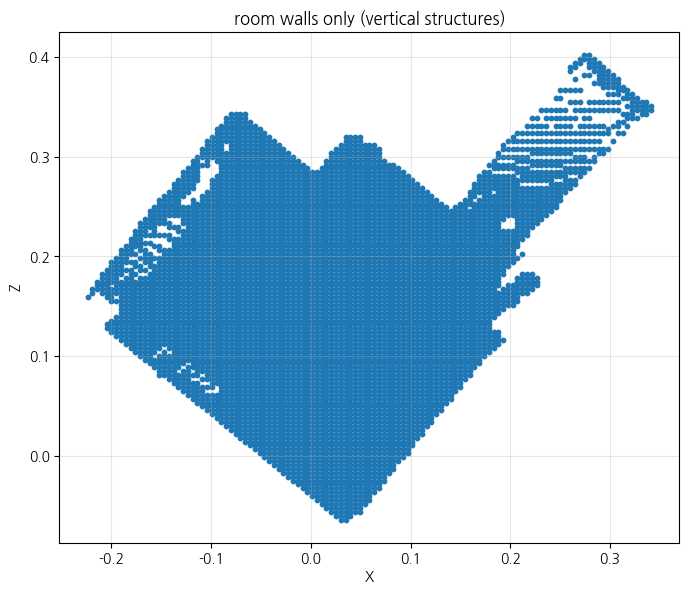

In [93]:
import numpy as np
import matplotlib.pyplot as plt

pts = all_pts[np.isfinite(all_pts).all(axis=1)]

X = pts[:, 0]
Y = pts[:, 1]   # 위 방향
Z = pts[:, 2]

# 전체 높이 범위 (양 끝 이상치 제거)
y_lo, y_hi = np.percentile(Y, 1), np.percentile(Y, 99)
height = y_hi - y_lo

# 위에서 본 평면(X-Z)을 격자로 분할
n_bins = 120
xedges = np.linspace(X.min(), X.max(), n_bins + 1)
zedges = np.linspace(Z.min(), Z.max(), n_bins + 1)
ix = np.clip(np.digitize(X, xedges) - 1, 0, n_bins - 1)
iz = np.clip(np.digitize(Z, zedges) - 1, 0, n_bins - 1)

# 각 칸의 점 높이 최소/최대/개수
cell_min = np.full((n_bins, n_bins), np.inf)
cell_max = np.full((n_bins, n_bins), -np.inf)
cell_cnt = np.zeros((n_bins, n_bins), dtype=int)
np.minimum.at(cell_min, (ix, iz), Y)
np.maximum.at(cell_max, (ix, iz), Y)
np.add.at(cell_cnt, (ix, iz), 1)

vspan = cell_max - cell_min   # 칸별 세로 높이 범위

# 벽 조건: 세로로 충분히 길고 + 점이 어느 정도 있는 칸
span_thr = height * 0.5   # 전체 높이의 50% 이상 차지하면 벽으로 간주
cnt_thr = 5
wall_mask = (vspan > span_thr) & (cell_cnt >= cnt_thr)

xc = (xedges[:-1] + xedges[1:]) / 2
zc = (zedges[:-1] + zedges[1:]) / 2
wx, wz = np.where(wall_mask)

plt.figure(figsize=(8, 8))
plt.scatter(xc[wx], zc[wz], s=10)
plt.title("room walls only (vertical structures)")
plt.xlabel("X"); plt.ylabel("Z")
plt.gca().set_aspect("equal")
plt.grid(True, alpha=0.3)
plt.show()


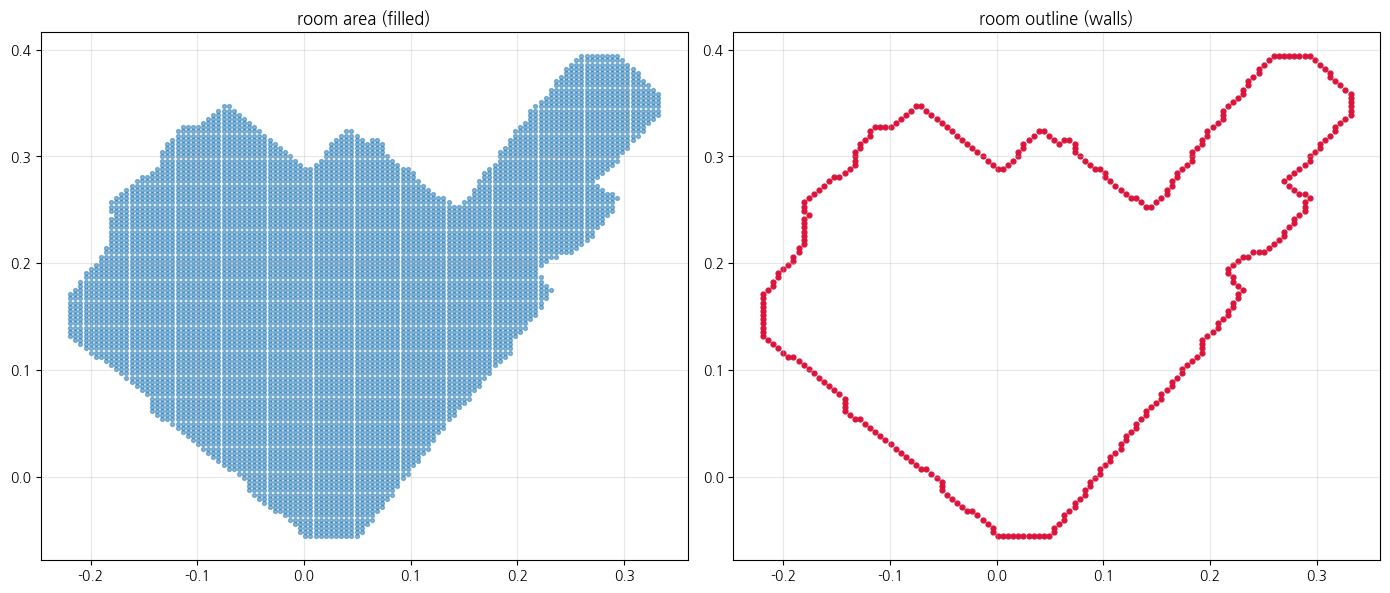

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

pts = all_pts[np.isfinite(all_pts).all(axis=1)]
X, Y, Z = pts[:, 0], pts[:, 1], pts[:, 2]

# 위에서 본 점유 격자 (점이 있는 칸 = 1)
n_bins = 120
xedges = np.linspace(X.min(), X.max(), n_bins + 1)
zedges = np.linspace(Z.min(), Z.max(), n_bins + 1)
ix = np.clip(np.digitize(X, xedges) - 1, 0, n_bins - 1)
iz = np.clip(np.digitize(Z, zedges) - 1, 0, n_bins - 1)

occ = np.zeros((n_bins, n_bins), dtype=bool)
occ[ix, iz] = True

# 잡음 정리: 구멍 메우고 작은 점 제거
occ = ndimage.binary_closing(occ, iterations=2)
occ = ndimage.binary_fill_holes(occ)
occ = ndimage.binary_opening(occ, iterations=1)

# 가장 큰 덩어리만 남기기 (방 본체)
labels, n = ndimage.label(occ)
if n > 1:
    sizes = ndimage.sum(occ, labels, range(1, n + 1))
    occ = labels == (np.argmax(sizes) + 1)

# 경계선만 추출 (채워진 영역 - 안쪽으로 깎은 영역 = 테두리)
boundary = occ & ~ndimage.binary_erosion(occ)

xc = (xedges[:-1] + xedges[1:]) / 2
zc = (zedges[:-1] + zedges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 채워진 방 영역
fx, fz = np.where(occ)
axes[0].scatter(xc[fx], zc[fz], s=8, alpha=0.5)
axes[0].set_title("room area (filled)")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3)

# 바깥 윤곽선만
bx, bz = np.where(boundary)
axes[1].scatter(xc[bx], zc[bz], s=12, color="crimson")
axes[1].set_title("room outline (walls)")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


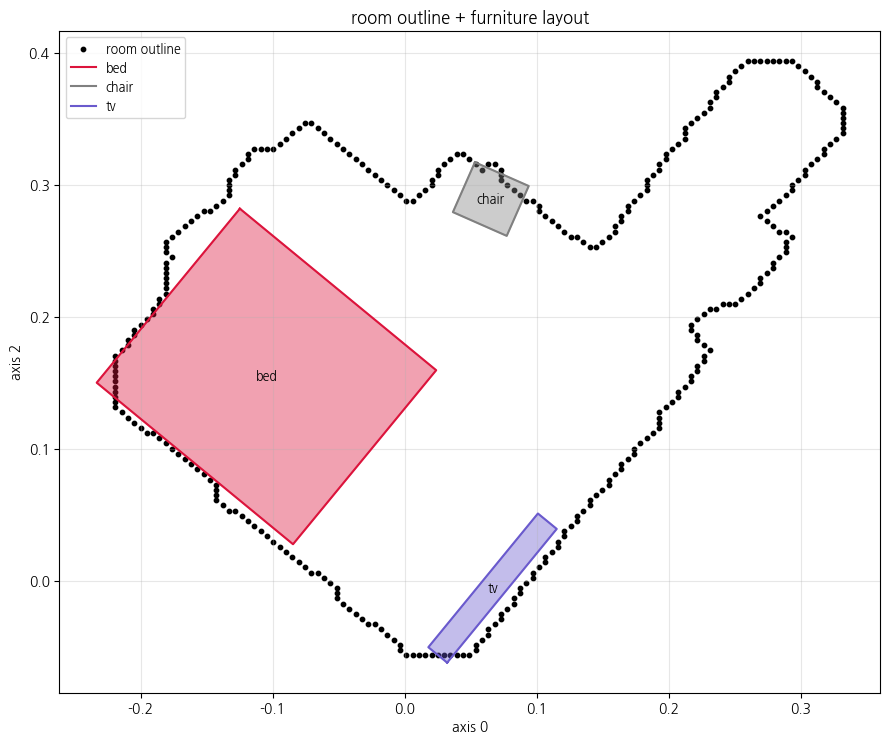

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.spatial import ConvexHull

# v1 메모리의 all_pts(방 전체)와 objects_3d(라벨별 가구 점) 사용
# 둘 다 GLB export 이전의 동일한 원본 좌표계라 그대로 얹힌다

UP_AXIS = 1   # 위 방향
plane = [a for a in range(3) if a != UP_AXIS]   # 평면 두 축 = [0, 2]

pts = all_pts[np.isfinite(all_pts).all(axis=1)]
P = pts[:, plane]   # (N, 2) 평면 투영

# --- 방 점유 격자 ---
n_bins = 120
e0 = np.linspace(P[:, 0].min(), P[:, 0].max(), n_bins + 1)
e1 = np.linspace(P[:, 1].min(), P[:, 1].max(), n_bins + 1)
i0 = np.clip(np.digitize(P[:, 0], e0) - 1, 0, n_bins - 1)
i1 = np.clip(np.digitize(P[:, 1], e1) - 1, 0, n_bins - 1)

occ = np.zeros((n_bins, n_bins), dtype=bool)
occ[i0, i1] = True
occ = ndimage.binary_closing(occ, iterations=2)
occ = ndimage.binary_fill_holes(occ)
occ = ndimage.binary_opening(occ, iterations=1)
labels, n = ndimage.label(occ)
if n > 1:
    sizes = ndimage.sum(occ, labels, range(1, n + 1))
    occ = labels == (np.argmax(sizes) + 1)

c0 = (e0[:-1] + e0[1:]) / 2
c1 = (e1[:-1] + e1[1:]) / 2


# --- 가구 발자국: minAreaRect (회전 최소 외접 사각형) ---
def min_area_rect(p2):
    hull = ConvexHull(p2)
    hp = p2[hull.vertices]
    best_area = np.inf
    best_box = None
    for i in range(len(hp)):
        edge = hp[(i + 1) % len(hp)] - hp[i]
        ang = np.arctan2(edge[1], edge[0])
        c, s = np.cos(ang), np.sin(ang)
        R = np.array([[c, s], [-s, c]])
        rot = hp @ R.T
        xmn, xmx = rot[:, 0].min(), rot[:, 0].max()
        ymn, ymx = rot[:, 1].min(), rot[:, 1].max()
        if (xmx - xmn) * (ymx - ymn) < best_area:
            best_area = (xmx - xmn) * (ymx - ymn)
            corners = np.array([[xmn, ymn], [xmx, ymn], [xmx, ymx], [xmn, ymx]])
            best_box = corners @ R
    return best_area, best_box


LABEL_COLORS = {"bed": "crimson", "refrigerator": "seagreen",
                "couch": "darkorange", "tv": "slateblue",
                "sink": "steelblue", "microwave": "gold"}

# --- 그리기 ---
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

# 방 외곽선 (격자 테두리)
boundary = occ & ~ndimage.binary_erosion(occ)
ba, bb = np.where(boundary)
ax.scatter(c0[ba], c1[bb], s=10, color="black", label="room outline")

# 가구 발자국 얹기
for label, opts in objects_3d.items():
    o = np.asarray(opts)
    o = o[np.isfinite(o).all(axis=1)]
    if len(o) < 3:
        continue
    o2 = o[:, plane]
    area, box = min_area_rect(o2)
    col = LABEL_COLORS.get(label, "gray")
    poly = np.vstack([box, box[0]])
    ax.fill(poly[:, 0], poly[:, 1], alpha=0.4, color=col)
    ax.plot(poly[:, 0], poly[:, 1], color=col, lw=1.5, label=label)
    cx, cy = box[:, 0].mean(), box[:, 1].mean()
    ax.text(cx, cy, label, ha="center", va="center", fontsize=9, weight="bold")

ax.set_aspect("equal")
ax.set_title("room outline + furniture layout")
ax.set_xlabel(f"axis {plane[0]}")
ax.set_ylabel(f"axis {plane[1]}")
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
